Shape: (24803, 20)

First 5 Rows
           x          y region     country reportingDate   cld   dtr    frs  \
0  90.380931  22.437184   Asia  Bangladesh     10/9/2020  41.6  12.8   0.00   
1  87.854975  22.986757   Asia       India    20/12/2019  40.5  13.3   0.00   
2  85.279935  23.610181   Asia       India    20/12/2019  27.3  13.6   0.08   
3  81.564510  43.882221   Asia       China    25/10/2019  45.3  12.8  31.00   
4  81.161057  43.834976   Asia       China    25/10/2019  38.8  13.2  31.00   

   pet   pre   tmn   tmp   tmx   vap   wet  elevation  dominant_land_cover  \
0  2.3   1.7  12.7  19.1  25.5  15.7  0.00        147                    2   
1  2.4   0.0  13.2  19.8  26.5  16.3  0.00        145                    2   
2  2.3   0.6   9.4  16.2  23.0  13.0  0.98        158                    2   
3  0.4   8.8 -22.5 -16.1  -9.7   0.9  4.64        178                    2   
4  0.4  10.5 -20.4 -13.8  -7.2   1.2  1.69        185                    3   

   X5_Ct_2010_Da  X5_Bf

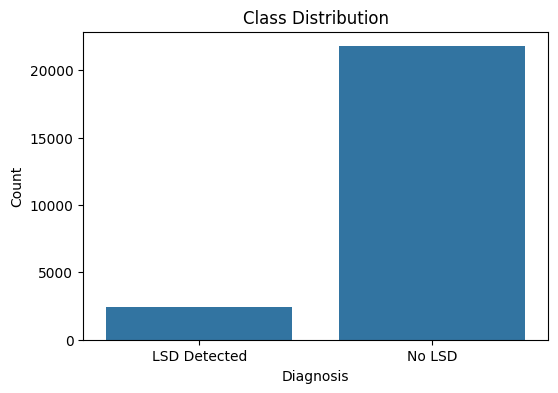

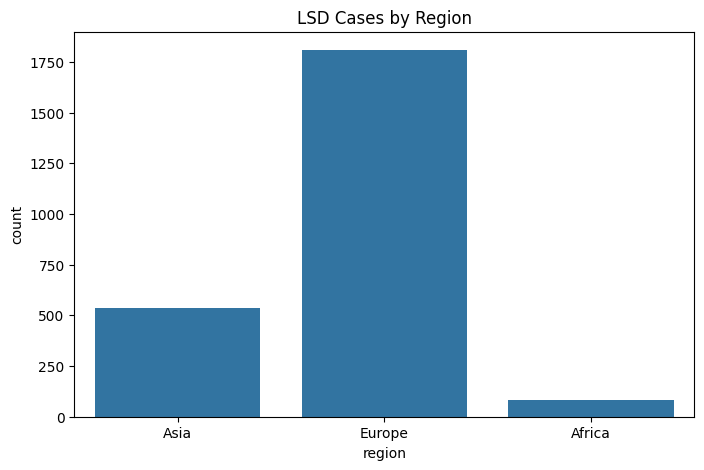

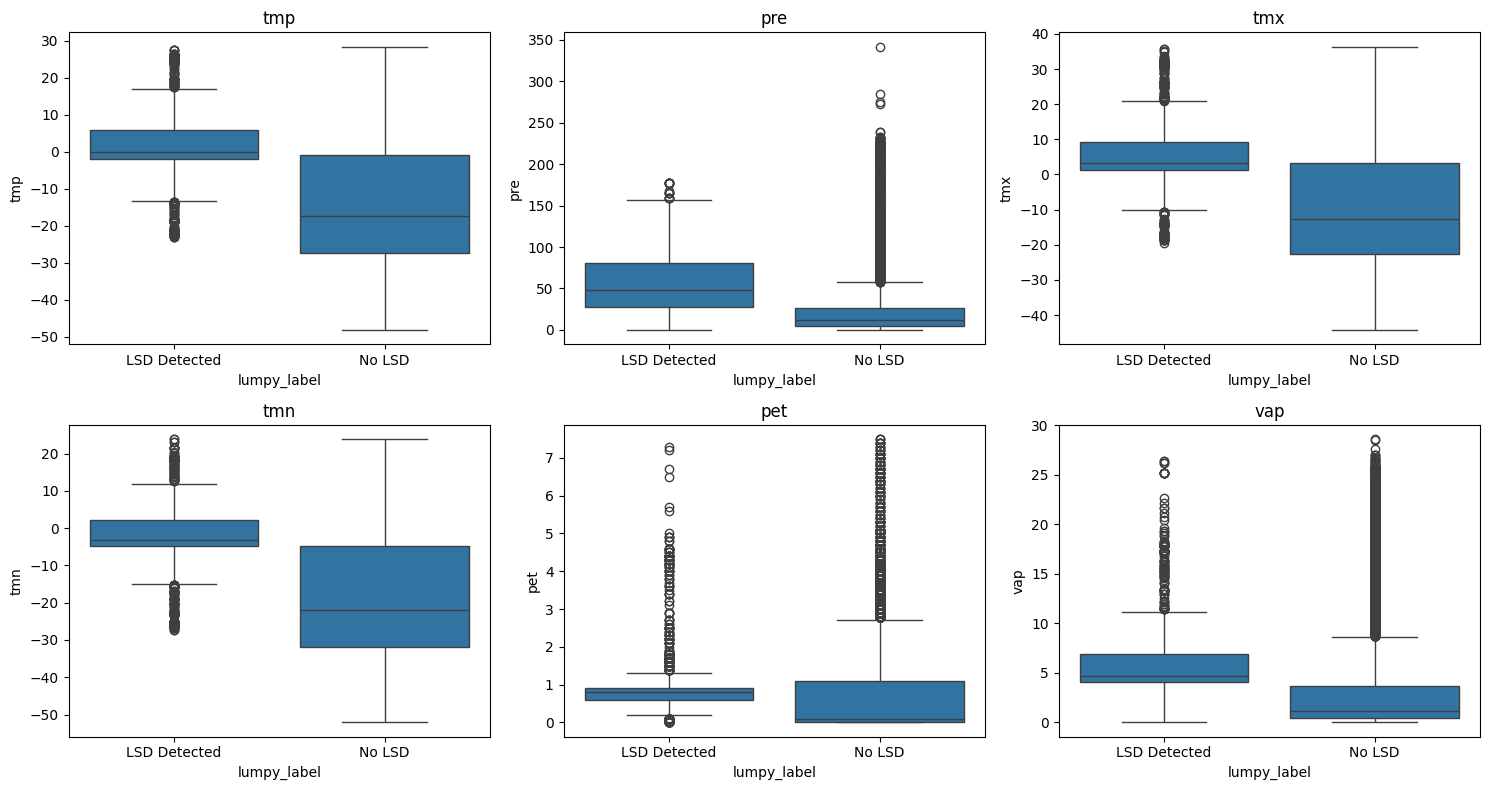

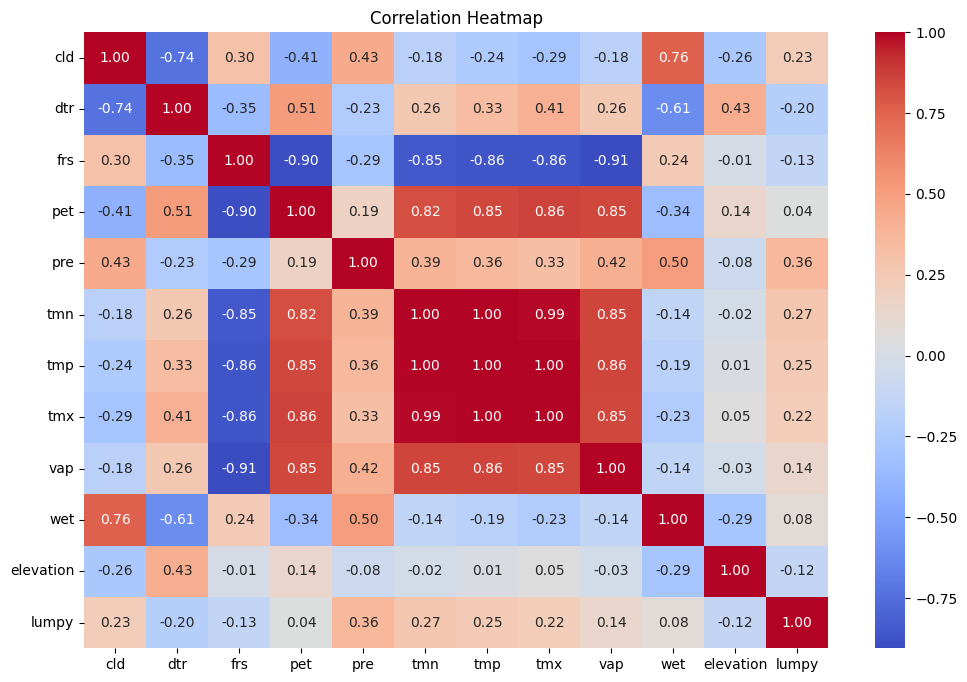


PC1 Variance: 53.85
PC2 Variance: 24.8


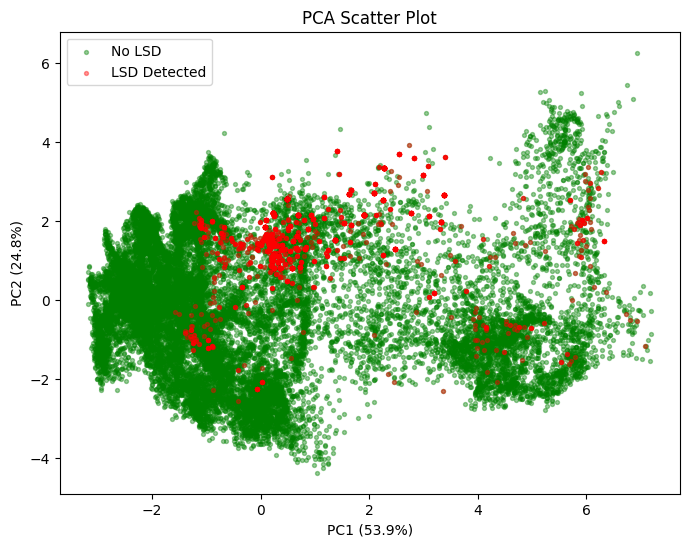

In [3]:
# ==========================================
# LUMPY SKIN DISEASE DETECTION
# PREPROCESSING + EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Lumpy skin disease data.csv")

print("Shape:", df.shape)

print("\nFirst 5 Rows")
print(df.head())

# ==========================================
# MISSING VALUES
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# DUPLICATES
# ==========================================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# ==========================================
# CREATE LABEL COLUMN
# ==========================================

df["lumpy_label"] = df["lumpy"].map({
    0: "No LSD",
    1: "LSD Detected"
})

# ==========================================
# LOG TRANSFORMATION
# ==========================================

df["log_cattle"] = np.log1p(df["X5_Ct_2010_Da"])
df["log_buffalo"] = np.log1p(df["X5_Bf_2010_Da"])

# ==========================================
# STATISTICAL SUMMARY
# ==========================================

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# CLASS DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="lumpy_label",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

# ==========================================
# REGION DISTRIBUTION
# ==========================================

df_pos = df.dropna(subset=["region"])

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_pos,
    x="region"
)

plt.title("LSD Cases by Region")

plt.show()

# ==========================================
# CLIMATE FEATURE BOXPLOTS
# ==========================================

climate_vars = [
    "tmp",
    "pre",
    "tmx",
    "tmn",
    "pet",
    "vap"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

axes = axes.flatten()

for i, var in enumerate(climate_vars):

    sns.boxplot(
        data=df,
        x="lumpy_label",
        y=var,
        ax=axes[i]
    )

    axes[i].set_title(var)

plt.tight_layout()

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

numeric_cols = [
    'cld',
    'dtr',
    'frs',
    'pet',
    'pre',
    'tmn',
    'tmp',
    'tmx',
    'vap',
    'wet',
    'elevation',
    'lumpy'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# FEATURE SCALING
# ==========================================

features = [
    'cld',
    'dtr',
    'frs',
    'pet',
    'pre',
    'tmn',
    'tmp',
    'tmx',
    'vap',
    'wet',
    'elevation'
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df[features])

# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

print(
    "\nPC1 Variance:",
    round(pca.explained_variance_ratio_[0]*100,2)
)

print(
    "PC2 Variance:",
    round(pca.explained_variance_ratio_[1]*100,2)
)

# ==========================================
# PCA SCATTER PLOT
# ==========================================

plt.figure(figsize=(8,6))

for label, color in zip(
    [0,1],
    ["green","red"]
):

    mask = df["lumpy"] == label

    plt.scatter(
        pcs[mask,0],
        pcs[mask,1],
        c=color,
        alpha=0.4,
        s=8,
        label="No LSD" if label==0 else "LSD Detected"
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("PCA Scatter Plot")

plt.legend()

plt.show()